# Capítulo 2 — Pre-procesamiento de Datos

**Libro de referencia**: Evsukoff, A. (2020). *Inteligência Computacional: Fundamentos e Aplicações*. Río de Janeiro: E-papers.

**Curso**: Inteligencia Computacional — Magíster en Ingeniería USACH (Prof. Max Chacón).

**Resumen base**: `data/raw/Libros/livro-official/resumenes/es/cap2_pre-procesamiento_resumen.tex`

---

## Objetivo del notebook

Recorrer **toda** la cadena de pre-procesamiento descrita en el capítulo, alternando:

1. **Teoría matemática** rigurosa (notación del libro: $\mathbf{X}\in\mathbb{R}^{N\times p}$, $\mathbf{Y}\in\mathbb{R}^{N\times q}$).
2. **Ejemplos numéricos** sintéticos pequeños donde se pueda verificar a mano.
3. **Aplicación** sobre un dataset biomédico real (`heart_failure_clinical_records_dataset.csv`).

## Plan

| Sección | Contenido |
|---|---|
| 0 | Setup, carga de dataset y notación |
| 1 | Caracterización estadística univariada |
| 2 | Caracterización multivariada (covarianza, correlación) |
| 3 | Distancias y similitudes |
| 4 | Estandarización (min–max, z-score, log) |
| 5 | Detección de outliers (3σ, IQR, Algoritmo 2.1 por distancia) |
| 6 | Valores faltantes (Algoritmo 2.2 — imputación kNN) |
| 7 | Análisis de Componentes Principales (ACP) |
| 8 | Descomposición en Valores Singulares (SVD) y su relación con ACP |
| 9 | Análisis Discriminante Lineal (ADL/LDA) |
| 10 | Análisis de Correlación Canónica (ACC/CCA) |
| 11 | Aplicación: ecuaciones de paridad para validación de sensores |
| 12 | Conclusiones |

## 0. Setup y notación

**Convenciones** (Evsukoff, Cap. 2):

- Conjunto de datos: $\mathcal{T}=\{(\mathbf{x}(t),\mathbf{y}(t)): t=1,\dots,N\}$.
- $\mathbf{x}(t)\in\mathbb{R}^p$ es la $t$-ésima observación (fila); $\mathbf{y}(t)\in\mathbb{R}^q$ es su salida (si existe).
- $\mathbf{X}\in\mathbb{R}^{N\times p}$ es la matriz de datos.
- Vectores: minúsculas en negrita ($\mathbf{x}$). Matrices: mayúsculas en negrita ($\mathbf{X}$). Escalares: cursiva ($x$). Conjuntos: caligráficas ($\mathcal{T}$).

Tipos de variables:

- **Continuas** ($\mathbb{R}$): edad, presión, temperatura.
- **Discretas ordenadas** ($\mathbb{N}$ con orden): nivel educacional, escala Likert.
- **Categóricas / nominales**: sexo, color, diagnóstico (codificadas como *dummies* binarias).

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform, cdist
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cross_decomposition import CCA
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.datasets import load_iris, load_wine

rng = np.random.default_rng(42)
sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Resolución robusta del path del dataset (sirve si el kernel arranca en cualquier carpeta del repo)
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data' / 'raw' / 'datasets').is_dir():
            return p
    raise FileNotFoundError('No se encontró la raíz del repo data-inteligencia')

ROOT = _find_repo_root(Path.cwd())
DATA_PATH = ROOT / 'data' / 'raw' / 'datasets' / 'heart_failure_clinical_records_dataset.csv'
df_hf = pd.read_csv(DATA_PATH)
print('Repo root:', ROOT)
print('Forma del dataset (N, p):', df_hf.shape)
df_hf.head()

Repo root: c:\Developer\data-inteligencia
Forma del dataset (N, p): (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Variables continuas vs binarias
cont_vars = ['age','creatinine_phosphokinase','ejection_fraction','platelets',
             'serum_creatinine','serum_sodium','time']
bin_vars  = ['anaemia','diabetes','high_blood_pressure','sex','smoking']
target    = 'DEATH_EVENT'

X_full = df_hf[cont_vars].to_numpy(dtype=float)
y_full = df_hf[target].to_numpy(dtype=int)
N, p = X_full.shape
print(f'N = {N}, p = {p} (variables continuas)')
print(f'Tasa de evento (DEATH=1): {y_full.mean():.3f}')

N = 299, p = 7 (variables continuas)
Tasa de evento (DEATH=1): 0.321


## 1. Caracterización estadística univariada

### 1.1 Medidas de centralidad y dispersión

Para cada variable $x_i$ con $N$ observaciones $\{x_i(1),\dots,x_i(N)\}$:

$$
\bar{x}_i = \frac{1}{N}\sum_{t=1}^{N}x_i(t), \qquad
\hat{\sigma}_i^2 = \frac{1}{N-1}\sum_{t=1}^{N}\bigl(x_i(t)-\bar{x}_i\bigr)^2.
$$

El **denominador $N-1$** (corrección de Bessel) hace al estimador insesgado para muestras finitas.

Robustas a *outliers*:

- **Mediana** $= P_{50}$.
- **Cuartiles** $Q_1=P_{25}$, $Q_3=P_{75}$.
- **Rango intercuartílico** $\mathrm{IQR}=Q_3-Q_1$.
- **Moda** (más frecuente).

**Diagnóstico clave**: si $\bar{x}\not\approx \text{mediana}$, hay asimetría (skewness).

In [4]:
def resumen_univariado(df, columnas):
    rows = []
    for c in columnas:
        x = df[c].to_numpy(dtype=float)
        rows.append({
            'variable': c,
            'media':    np.mean(x),
            'mediana':  np.median(x),
            'std':      np.std(x, ddof=1),
            'min':      np.min(x),
            'Q1':       np.percentile(x, 25),
            'Q3':       np.percentile(x, 75),
            'max':      np.max(x),
            'IQR':      np.percentile(x, 75) - np.percentile(x, 25),
            'skew':     stats.skew(x),
            'kurt':     stats.kurtosis(x),  # exceso (0 = normal)
        })
    return pd.DataFrame(rows).set_index('variable').round(3)

resumen_univariado(df_hf, cont_vars)

,media,mediana,std,min,Q1,Q3,max,IQR,skew,kurt
variable,,,,,,,,,,
age,60.834,60.0,11.895,40.0,51.0,70.0,95.0,19.0,0.421,-0.202
creatinine_phosphokinase,581.839,250.0,970.288,23.0,116.5,582.0,7861.0,465.5,4.441,24.710
ejection_fraction,38.084,38.0,11.835,14.0,30.0,45.0,80.0,15.0,0.553,0.021
platelets,263358.029,262000.0,97804.237,25100.0,212500.0,303500.0,850000.0,91000.0,1.455,6.086
serum_creatinine,1.394,1.1,1.035,0.5,0.9,1.4,9.4,0.5,4.434,25.378
serum_sodium,136.625,137.0,4.412,113.0,134.0,140.0,148.0,6.0,-1.043,4.031
time,130.261,115.0,77.614,4.0,73.0,203.0,285.0,130.0,0.127,-1.212


**Lectura del cuadro:**
- `creatinine_phosphokinase`: media $\approx 581$ vs mediana $\approx 250$ + skew $\approx 4.4$ ⇒ **fuertemente asimétrica a la derecha**, candidata a transformación $\log$.
- `platelets`: skew $\approx 1.5$, kurt $> 0$ ⇒ colas pesadas, posibles outliers.
- `age`, `serum_sodium`, `ejection_fraction`: skew moderado, comportamiento más cercano a normal.

### 1.2 La distribución normal y el TCL

Densidad gaussiana:

$$
f(x;\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

**Teorema Central del Límite (TCL)**: si $X_1,\dots,X_n$ son iid con media $\mu$ y varianza $\sigma^2<\infty$, entonces

$$
\sqrt{n}\,\frac{\bar{X}_n-\mu}{\sigma}\xrightarrow{d} \mathcal{N}(0,1).
$$

Esto justifica que la gaussiana aparezca *naturalmente* en estimadores muestrales y como **función de base** en RBF y SVM (Cap. 7).

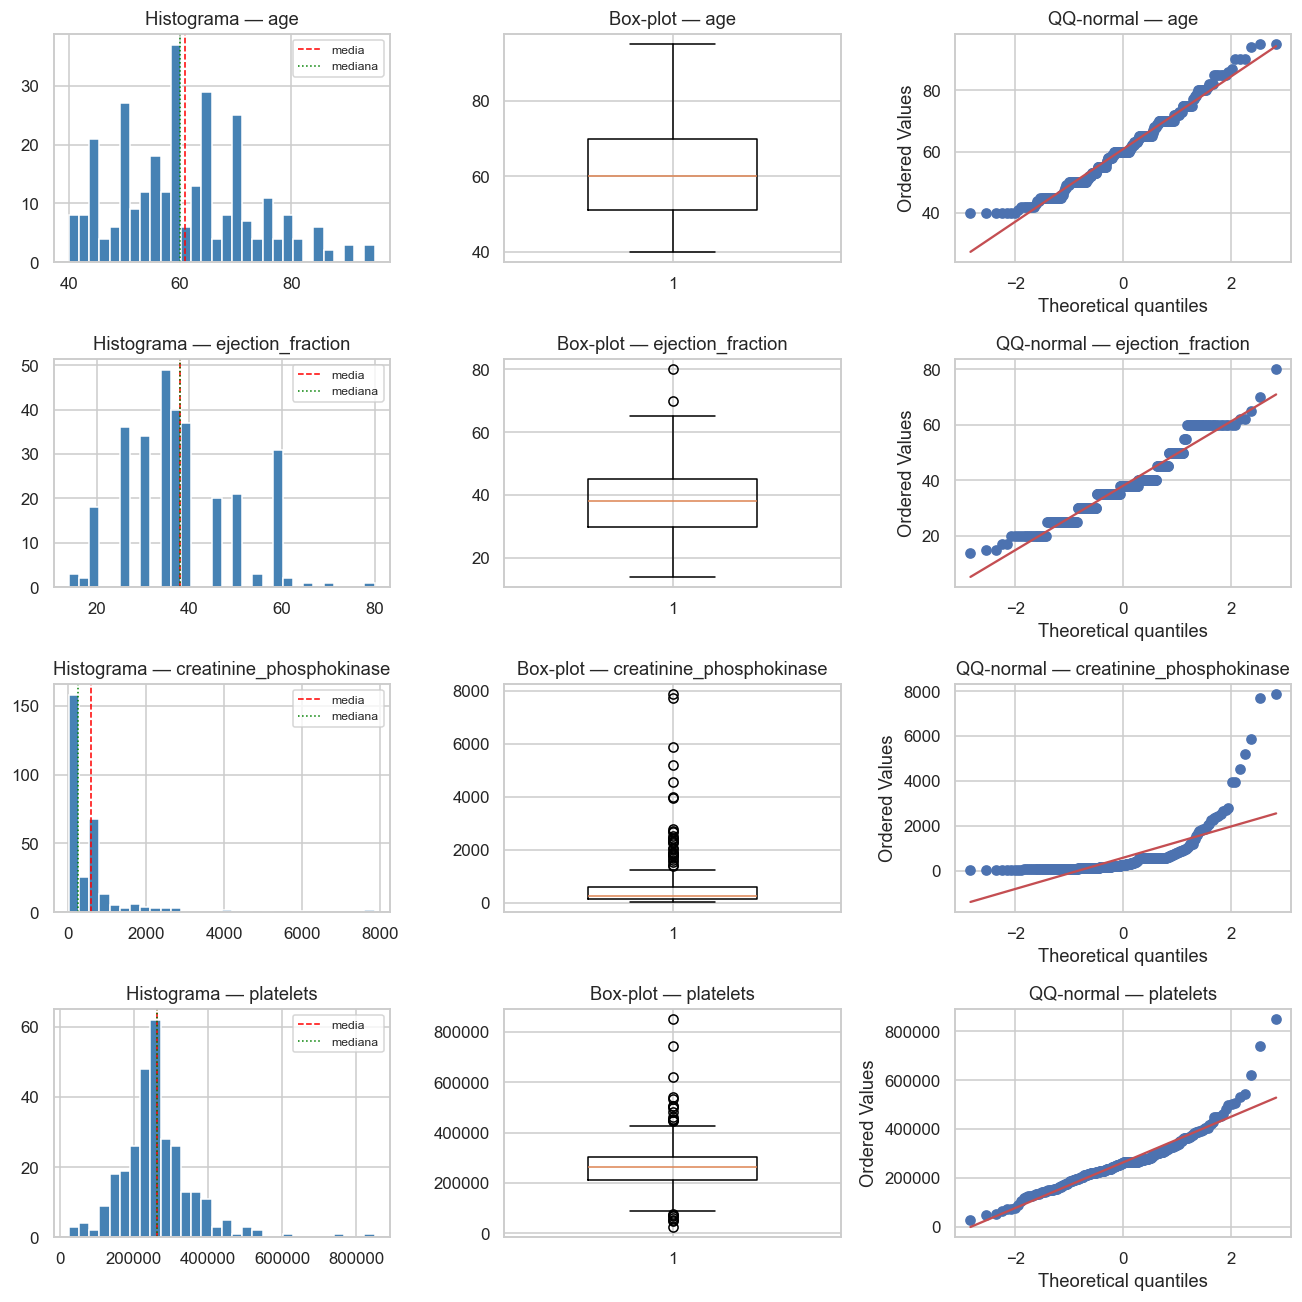

In [5]:
# Ejercicio 1.1 — Visualización: histograma + boxplot + QQ-plot para 4 variables
vars_plot = ['age', 'ejection_fraction', 'creatinine_phosphokinase', 'platelets']
fig, axes = plt.subplots(len(vars_plot), 3, figsize=(12, 3.0*len(vars_plot)))
for i, v in enumerate(vars_plot):
    x = df_hf[v].to_numpy(float)
    axes[i,0].hist(x, bins=30, color='steelblue', edgecolor='white')
    axes[i,0].axvline(np.mean(x), color='red', ls='--', lw=1, label='media')
    axes[i,0].axvline(np.median(x), color='green', ls=':', lw=1, label='mediana')
    axes[i,0].set_title(f'Histograma — {v}'); axes[i,0].legend(fontsize=8)
    axes[i,1].boxplot(x, vert=True, widths=0.5)
    axes[i,1].set_title(f'Box-plot — {v}')
    stats.probplot(x, dist='norm', plot=axes[i,2])
    axes[i,2].set_title(f'QQ-normal — {v}')
plt.tight_layout(); plt.show()

**Lectura QQ-plot:** si los puntos caen sobre la recta diagonal, los datos son aproximadamente normales. Curvas tipo "S" o despegues en los extremos indican colas pesadas/asimetría.

### 1.3 Ejercicio 1.2 — Test de normalidad y transformación log

Verificamos numéricamente con el test de **Shapiro–Wilk** ($H_0$: la muestra proviene de una normal) y aplicamos $\log(x+1)$ a una variable asimétrica.

CPK original    Shapiro W = 0.5143  p = 7.05e-28  skew = +4.441
log(1+CPK)      Shapiro W = 0.9679  p = 3.37e-06  skew = +0.421


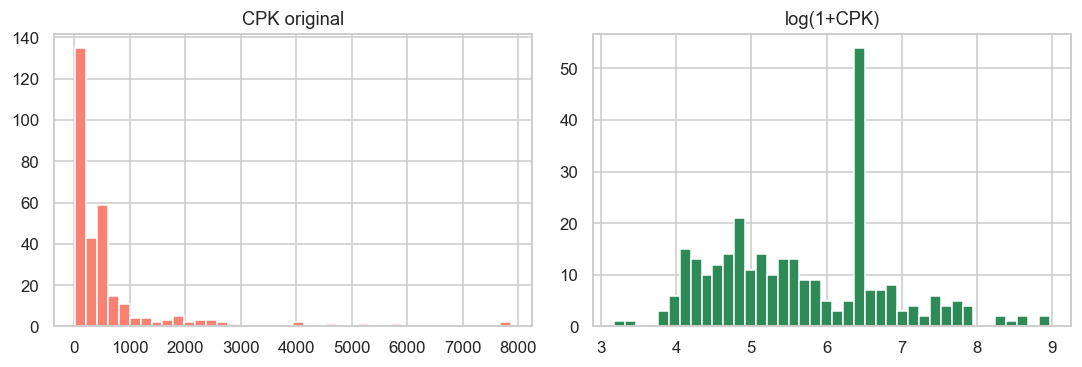

In [6]:
x = df_hf['creatinine_phosphokinase'].to_numpy(float)
x_log = np.log1p(x)

for nombre, serie in [('CPK original', x), ('log(1+CPK)', x_log)]:
    W, p_val = stats.shapiro(serie)
    print(f'{nombre:14s}  Shapiro W = {W:.4f}  p = {p_val:.2e}  skew = {stats.skew(serie):+.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10,3.5))
ax[0].hist(x, bins=40, color='salmon', edgecolor='white'); ax[0].set_title('CPK original')
ax[1].hist(x_log, bins=40, color='seagreen', edgecolor='white'); ax[1].set_title('log(1+CPK)')
plt.tight_layout(); plt.show()

La transformación logarítmica reduce drásticamente la skewness y acerca la variable a una normal — paso útil **antes** del z-score si la distribución es muy asimétrica.

## 2. Caracterización multivariada

### 2.1 Matriz de covarianzas

Sea $\mathbf{X}_c = \mathbf{X} - \mathbf{1}\bar{\mathbf{x}}^{\top}$ la matriz centrada. Entonces

$$
\hat{\boldsymbol{\Sigma}} \;=\; \frac{1}{N-1}\,\mathbf{X}_c^{\top}\mathbf{X}_c \;\in\;\mathbb{R}^{p\times p}.
$$

Propiedades:

- **Simétrica**: $\hat{\boldsymbol{\Sigma}}^{\top}=\hat{\boldsymbol{\Sigma}}$.
- **Semidefinida positiva**: $\mathbf{v}^{\top}\hat{\boldsymbol{\Sigma}}\mathbf{v}\geq 0\;\forall \mathbf{v}$.
- Diagonal: $\hat{\sigma}_{ii}^2 = \hat{\sigma}_i^2$ (varianzas).
- Off-diagonal: $\hat{\sigma}_{ij} = \widehat{\mathrm{Cov}}(x_i,x_j)$.

### 2.2 Matriz de correlación de Pearson

$$
\hat{\rho}_{ij} \;=\; \frac{\hat{\sigma}_{ij}}{\hat{\sigma}_i\,\hat{\sigma}_j} \;\in\; [-1,1].
$$

Equivalentemente, $\hat{\mathbf{R}} = \mathbf{D}^{-1/2}\hat{\boldsymbol{\Sigma}}\mathbf{D}^{-1/2}$ donde $\mathbf{D}=\mathrm{diag}(\hat{\sigma}_1^2,\dots,\hat{\sigma}_p^2)$.

**Cuidado**: $\hat{\rho}_{ij}=0$ excluye sólo dependencia *lineal*. Una relación cuadrática perfecta $y=x^2$ centrada da correlación $\approx 0$.

In [7]:
# Ejemplo numérico minúsculo: verificar fórmula a mano
X_demo = np.array([[1, 2],
                   [2, 4],
                   [3, 6],
                   [4, 7],
                   [5, 11]], dtype=float)
Xc = X_demo - X_demo.mean(axis=0)
Sigma = (Xc.T @ Xc) / (X_demo.shape[0] - 1)
D = np.diag(np.sqrt(np.diag(Sigma)))
R = np.linalg.inv(D) @ Sigma @ np.linalg.inv(D)
print('Sigma (calculada a mano):\n', Sigma)
print('np.cov:\n', np.cov(X_demo, rowvar=False))
print('R (Pearson):\n', R)
print('np.corrcoef:\n', np.corrcoef(X_demo, rowvar=False))

Sigma (calculada a mano):
 [[ 2.5   5.25]
 [ 5.25 11.5 ]]
np.cov:
 [[ 2.5   5.25]
 [ 5.25 11.5 ]]
R (Pearson):
 [[1.         0.97913005]
 [0.97913005 1.        ]]
np.corrcoef:
 [[1.         0.97913005]
 [0.97913005 1.        ]]


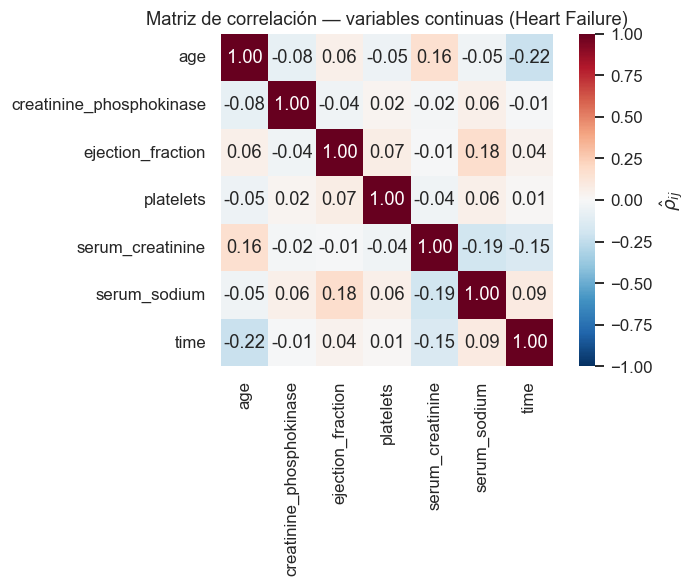

Top 5 pares por |corr|:
age                time                0.224
serum_creatinine   serum_sodium        0.189
ejection_fraction  serum_sodium        0.176
age                serum_creatinine    0.159
serum_creatinine   time                0.149
dtype: float64


In [8]:
# Ejercicio 2.1 — Matriz de correlación del dataset y mapa de calor
R_hf = df_hf[cont_vars].corr()
fig, ax = plt.subplots(figsize=(7,5.5))
sns.heatmap(R_hf, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label':'$\\hat{\\rho}_{ij}$'})
ax.set_title('Matriz de correlación — variables continuas (Heart Failure)')
plt.tight_layout(); plt.show()

# Pares con |corr| > 0.2 (ninguno es fuerte aquí — dataset poco redundante)
pares = (R_hf.where(np.triu(np.ones_like(R_hf, dtype=bool), k=1))
             .stack().abs().sort_values(ascending=False))
print('Top 5 pares por |corr|:')
print(pares.head(5).round(3))

Correlación de Pearson para y = x^2 + ruido:  rho = 0.0002


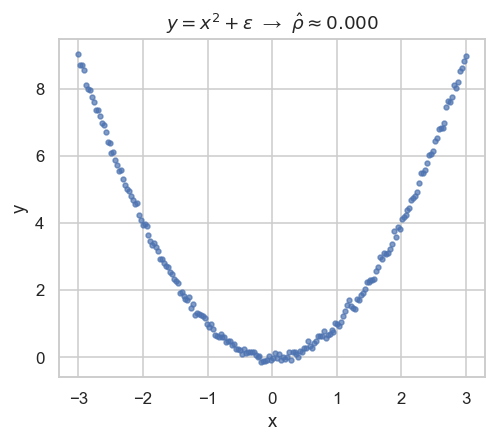

In [9]:
# Ejercicio 2.2 — Trampa de la correlación nula con relación NO lineal
x = np.linspace(-3, 3, 200)
y = x**2 + rng.normal(0, 0.1, size=x.size)
rho, _ = stats.pearsonr(x, y)
print(f'Correlación de Pearson para y = x^2 + ruido:  rho = {rho:.4f}')

fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(x, y, s=10, alpha=0.7)
ax.set_title(f'$y = x^2 + \\varepsilon$  →  $\\hat{{\\rho}} \\approx {rho:.3f}$')
ax.set_xlabel('x'); ax.set_ylabel('y'); plt.show()

**Conclusión**: la correlación es ≈ 0 a pesar de la dependencia *funcional perfecta*. Para detectar relaciones no lineales hay alternativas: información mutua, $\rho$ de Spearman (rangos), distancia de correlación.

## 3. Distancias y similitudes

Una **métrica** $d:\mathbb{R}^p\times\mathbb{R}^p\to\mathbb{R}_{\geq 0}$ debe cumplir:

1. $d(\mathbf{u},\mathbf{v})\geq 0$ y $=0 \iff \mathbf{u}=\mathbf{v}$,
2. simetría $d(\mathbf{u},\mathbf{v})=d(\mathbf{v},\mathbf{u})$,
3. desigualdad triangular $d(\mathbf{u},\mathbf{w})\leq d(\mathbf{u},\mathbf{v})+d(\mathbf{v},\mathbf{w})$.

| Nombre | Fórmula |
|---|---|
| Euclidiana ($L_2$) | $\sqrt{\sum_i (u_i-v_i)^2}$ |
| Manhattan ($L_1$) | $\sum_i |u_i-v_i|$ |
| Chebyshev ($L_\infty$) | $\max_i |u_i-v_i|$ |
| Minkowski ($L_r$) | $\bigl(\sum_i |u_i-v_i|^r\bigr)^{1/r}$ |
| Mahalanobis | $\sqrt{(\mathbf{u}-\mathbf{v})^{\top}\hat{\boldsymbol{\Sigma}}^{-1}(\mathbf{u}-\mathbf{v})}$ |

**Similitudes**:

$$
\mathrm{sim}_{C}(\mathbf{u},\mathbf{v}) \;=\; \frac{\langle\mathbf{u},\mathbf{v}\rangle}{\|\mathbf{u}\|\,\|\mathbf{v}\|},\qquad
\mathrm{sim}_{G}(\mathbf{u},\mathbf{v}) \;=\; \exp\!\left(-\frac{\|\mathbf{u}-\mathbf{v}\|^2}{2\sigma^2}\right).
$$

**Mahalanobis** es la única que *normaliza por la estructura de covarianza* — equivale a euclidiana sobre datos previamente decorrelacionados y estandarizados (lo veremos en ACP).

In [10]:
# Ejercicio 3.1 — Comparar distancias sobre 3 puntos sintéticos
u = np.array([1.0, 0.0])
v = np.array([4.0, 4.0])
w = np.array([0.0, 5.0])
P = np.vstack([u, v, w])

print('Pares (u-v), (u-w), (v-w):')
for nombre, metric in [('Euclidiana', 'euclidean'),
                       ('Manhattan',  'cityblock'),
                       ('Chebyshev',  'chebyshev'),
                       ('Minkowski r=3', None),
                       ('Coseno (1-sim)', 'cosine')]:
    if nombre.startswith('Minkowski'):
        d = pdist(P, metric='minkowski', p=3)
    else:
        d = pdist(P, metric=metric)
    print(f'  {nombre:18s}  {np.round(d, 3)}')

Pares (u-v), (u-w), (v-w):
  Euclidiana          [5.    5.099 4.123]
  Manhattan           [7. 6. 5.]
  Chebyshev           [4. 5. 4.]
  Minkowski r=3       [4.498 5.013 4.021]
  Coseno (1-sim)      [0.293 1.    0.293]


Distancia Euclidiana: 2.121
Distancia Mahalanobis: 6.654  ← mucho mayor: el punto es atípico para esta covarianza


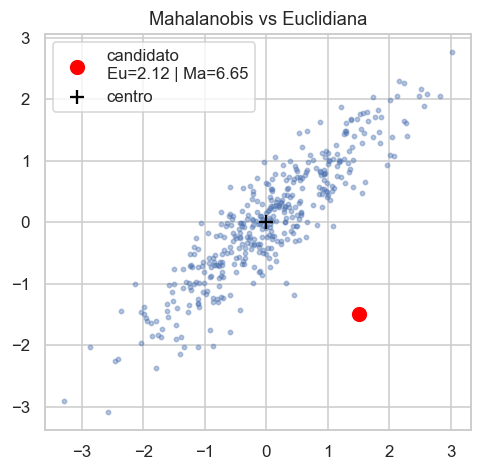

In [11]:
# Ejercicio 3.2 — Mahalanobis: por qué importa la covarianza
mean = np.array([0, 0])
cov  = np.array([[1.0, 0.9],
                 [0.9, 1.0]])  # variables muy correlacionadas
X_corr = rng.multivariate_normal(mean, cov, size=400)

candidato = np.array([1.5, -1.5])  # ortogonal a la dirección principal
centro    = mean

d_eu = np.linalg.norm(candidato - centro)
Sigma_inv = np.linalg.inv(np.cov(X_corr, rowvar=False))
d_ma = np.sqrt((candidato - centro) @ Sigma_inv @ (candidato - centro))

print(f'Distancia Euclidiana: {d_eu:.3f}')
print(f'Distancia Mahalanobis: {d_ma:.3f}  ← mucho mayor: el punto es atípico para esta covarianza')

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(X_corr[:,0], X_corr[:,1], s=8, alpha=0.4)
ax.scatter(*candidato, color='red', s=80, label=f'candidato\nEu={d_eu:.2f} | Ma={d_ma:.2f}')
ax.scatter(*centro, color='black', s=80, marker='+', label='centro')
ax.set_title('Mahalanobis vs Euclidiana')
ax.legend(); ax.set_aspect('equal'); plt.show()

El punto rojo está *cerca* en sentido Euclidiano, pero *lejos* en sentido Mahalanobis: cae fuera de la elipse de iso-densidad de la nube. Esta es la base para detección de *outliers* multivariados.

### 3.3 Data image: matriz $\mathbf{D}\in\mathbb{R}^{N\times N}$

Visualizar $d_{ij}=d(\mathbf{x}(i),\mathbf{x}(j))$ como imagen reordenada revela grupos.

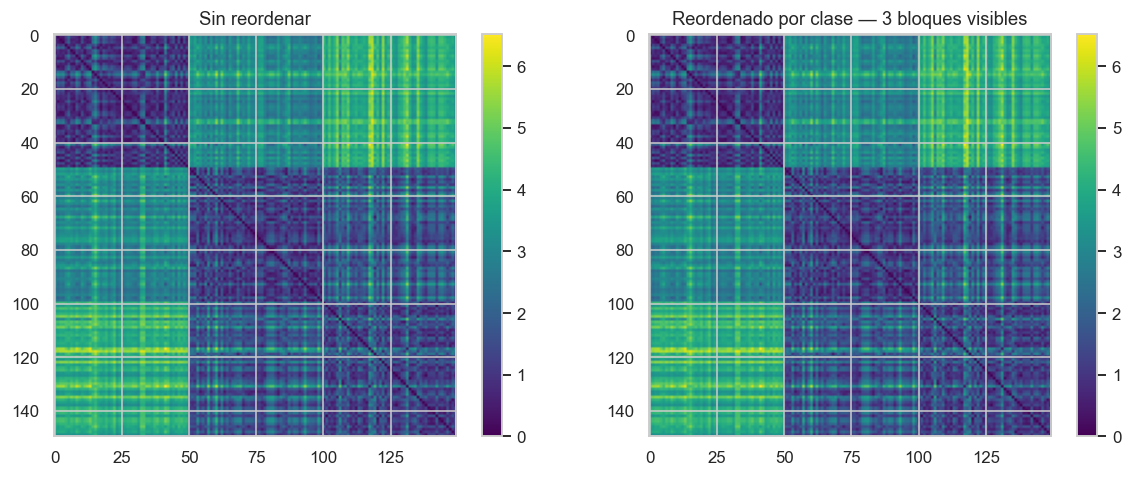

In [12]:
# Ejercicio 3.3 — Data image sobre Iris (3 clases obvias)
iris = load_iris()
Xi = StandardScaler().fit_transform(iris.data)
yi = iris.target
orden = np.argsort(yi)             # ordenar por clase para que aparezcan bloques
Xi_ord = Xi[orden]
D = squareform(pdist(Xi_ord, metric='euclidean'))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = ax[0].imshow(squareform(pdist(Xi, metric='euclidean')), cmap='viridis')
ax[0].set_title('Sin reordenar'); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(D, cmap='viridis')
ax[1].set_title('Reordenado por clase — 3 bloques visibles')
plt.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## 4. Estandarización

Necesaria porque variables con escalas distintas dominarían distancias y descomposiciones (especialmente ACP).

### 4.1 Min–max

$$
\hat{x}_i(t) \;=\; \frac{x_i(t)-x_i^{\min}}{x_i^{\max}-x_i^{\min}}\;\in\;[0,1].
$$

**Pro**: rango fijo. **Contra**: extremadamente sensible a *outliers* (un valor extremo aplasta el resto).  
**Variante robusta**: usar $P_5$ y $P_{95}$ en lugar de min/max y *clipear*.

### 4.2 z-score

$$
\hat{x}_i(t) \;=\; \frac{x_i(t)-\bar{x}_i}{\hat{\sigma}_i}.
$$

Resulta en media 0 y varianza 1. Es el estándar de facto para PCA/SVM/redes neuronales.

### 4.3 Log + z-score

Para variables muy asimétricas: $x \to \log(x+c) \to$ z-score.

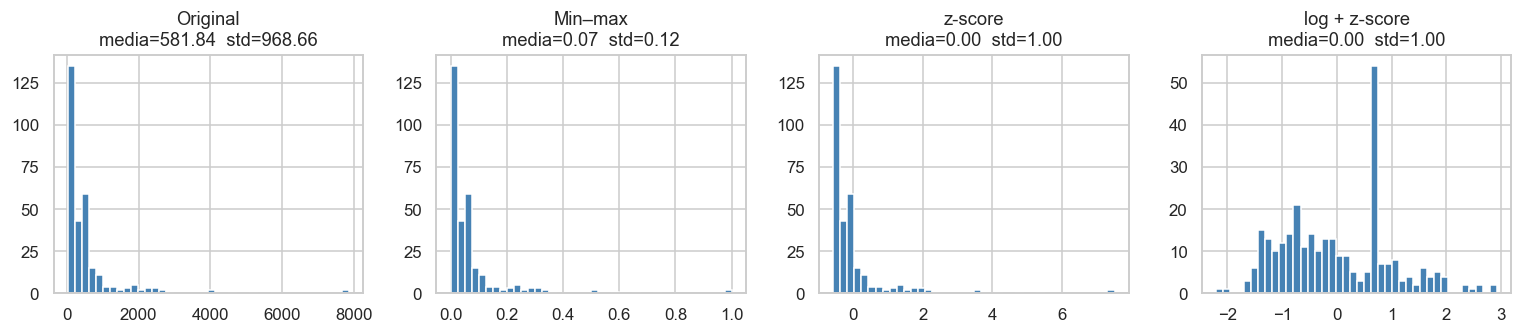

In [13]:
# Ejercicio 4.1 — Comparar tres estandarizaciones sobre CPK (variable asimétrica)
x = df_hf['creatinine_phosphokinase'].to_numpy(float).reshape(-1,1)
x_mm  = MinMaxScaler().fit_transform(x).ravel()
x_z   = StandardScaler().fit_transform(x).ravel()
x_lz  = StandardScaler().fit_transform(np.log1p(x)).ravel()

fig, ax = plt.subplots(1, 4, figsize=(14, 3.2))
for a, datos, t in zip(ax, [x.ravel(), x_mm, x_z, x_lz],
                       ['Original', 'Min–max', 'z-score', 'log + z-score']):
    a.hist(datos, bins=40, color='steelblue', edgecolor='white')
    a.set_title(f'{t}\nmedia={np.mean(datos):.2f}  std={np.std(datos):.2f}')
plt.tight_layout(); plt.show()

Observa cómo `min–max` deja casi todos los valores comprimidos en $[0, 0.1]$ por culpa de un outlier extremo — z-score sufre lo mismo en menor medida. La cadena `log → z-score` produce una distribución casi simétrica, mucho más útil para algoritmos sensibles a la geometría.

## 5. Detección de outliers

### 5.1 Por distribución (univariado)

Bajo $H_0:\;X\sim\mathcal{N}(\mu,\sigma^2)$:

$$
\Pr(|X-\mu|>3\sigma)\approx 0.0027.
$$

Regla práctica: marcar como sospechoso todo $x$ tal que $|x-\bar{x}|>3\hat{\sigma}$.

**Regla del box-plot (Tukey)**: outlier si

$$x < Q_1 - 1{.}5\,\mathrm{IQR} \quad \text{ó} \quad x > Q_3 + 1{.}5\,\mathrm{IQR}.$$

Esta regla **no asume normalidad** — usa cuartiles, es más robusta.

In [14]:
def outliers_3sigma(x):
    mu, sd = np.mean(x), np.std(x, ddof=1)
    return np.where(np.abs(x - mu) > 3*sd)[0]

def outliers_iqr(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return np.where((x < q1 - k*iqr) | (x > q3 + k*iqr))[0]

for v in cont_vars:
    x = df_hf[v].to_numpy(float)
    print(f'{v:30s}  3σ: {len(outliers_3sigma(x)):3d}   IQR: {len(outliers_iqr(x)):3d}')

age                             3σ:   0   IQR:   0
creatinine_phosphokinase        3σ:   7   IQR:  29
ejection_fraction               3σ:   1   IQR:   2
platelets                       3σ:   3   IQR:  21
serum_creatinine                3σ:   6   IQR:  29
serum_sodium                    3σ:   3   IQR:   4
time                            3σ:   0   IQR:   0


Ambas reglas actúan **variable a variable**: un registro puede ser "normal" en cada coordenada por separado y aún así ser un outlier multivariado.

### 5.2 Por distancia — Algoritmo 2.1 del libro

Idea: el outlier global es el registro más alejado *en promedio* del resto.

**Algoritmo 2.1** (Evsukoff, 2020):

1. Calcular matriz $\mathbf{D}\in\mathbb{R}^{N\times N}$ con $d_{ij}=\|\mathbf{x}(i)-\mathbf{x}(j)\|$ (sobre datos **estandarizados**).
2. Calcular distancia media de cada registro: $\bar{d}_i = \dfrac{1}{N}\sum_{j=1}^{N} d_{ij}$.
3. Ordenar $\bar{d}_i$ en forma decreciente.
4. Eliminar el $P_{\text{out}}\%$ superior.

Costo: $\mathcal{O}(N^2 p)$. Para $N$ grande conviene aproximar con kNN o Isolation Forest.

Detectados 15 outliers (5% superior).
Top 5 distancias medias: [8.587 8.394 7.008 6.496 6.097]


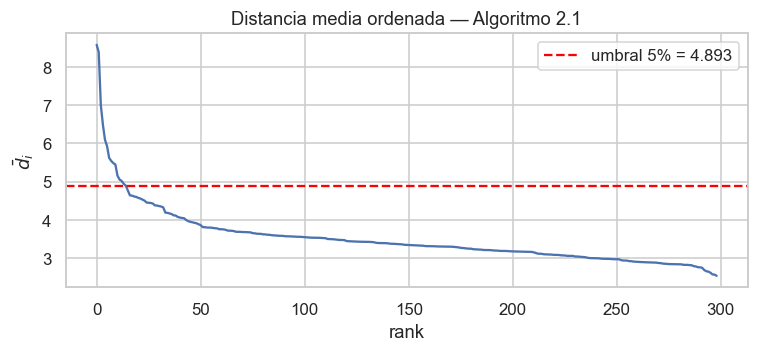

In [15]:
def algoritmo_2_1(X, p_out=0.05):
    """Detección de outliers por distancia media (Algoritmo 2.1, Evsukoff 2020).
    Devuelve índices de outliers y vector d_bar.
    Espera X ya estandarizado.
    """
    D = squareform(pdist(X, metric='euclidean'))
    d_bar = D.mean(axis=1)
    n_out = max(1, int(np.ceil(p_out * X.shape[0])))
    idx_out = np.argsort(d_bar)[::-1][:n_out]
    return idx_out, d_bar

# Sobre Heart Failure: estandarizamos primero (con log para CPK y platelets)
X_pre = df_hf[cont_vars].copy()
X_pre['creatinine_phosphokinase'] = np.log1p(X_pre['creatinine_phosphokinase'])
X_pre['platelets'] = np.log1p(X_pre['platelets'])
X_std = StandardScaler().fit_transform(X_pre.to_numpy())

idx_out, d_bar = algoritmo_2_1(X_std, p_out=0.05)
print(f'Detectados {len(idx_out)} outliers (5% superior).')
print('Top 5 distancias medias:', np.sort(d_bar)[::-1][:5].round(3))

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.sort(d_bar)[::-1], lw=1.5)
ax.axhline(d_bar[idx_out].min(), color='red', ls='--', label=f'umbral 5% = {d_bar[idx_out].min():.3f}')
ax.set_xlabel('rank'); ax.set_ylabel('$\\bar{d}_i$')
ax.set_title('Distancia media ordenada — Algoritmo 2.1')
ax.legend(); plt.show()

**Aviso**: en problemas de detección de fraude o anomalías médicas, los outliers **son el objeto de interés** y no deben removerse — sólo etiquetarse y/o derivarse a un modelo específico.

## 6. Valores faltantes — Algoritmo 2.2 (imputación kNN)

Estrategias estándar:

| Estrategia | Pros | Contras |
|---|---|---|
| Eliminar registros | Simple, sin sesgo de imputación | Puede perder mucha información |
| Eliminar variable | Útil si la columna está casi vacía | Pierdes señal |
| Imputar media/mediana | Trivial | Reduce varianza, distorsiona covarianzas |
| Imputar por kNN (Alg. 2.2) | Usa vecindad multivariada | $\mathcal{O}(N^2)$, requiere distancia |

**Algoritmo 2.2** (Evsukoff, 2020):

Para cada registro $\mathbf{x}(t)$ con valor faltante en variables $\mathcal{F}\subset\{1,\dots,p\}$:

1. Identificar variables observadas $\mathcal{O}=\{1,\dots,p\}\setminus\mathcal{F}$.
2. Calcular distancias en el subespacio $\mathcal{O}$ a todos los registros **completos**.
3. Tomar los $k\geq 3$ vecinos más cercanos $\mathcal{N}_k(t)$.
4. Imputar para cada $i\in\mathcal{F}$:
$$
\hat{x}_i(t) \;=\; \frac{\sum_{s\in\mathcal{N}_k(t)} w_{ts}\,x_i(s)}{\sum_{s\in\mathcal{N}_k(t)} w_{ts}},
\qquad w_{ts} = \frac{1}{d_{ts}+\varepsilon}.
$$

In [17]:
# Ejercicio 6.1 — Inducir faltantes y comparar imputación media vs kNN
# Usamos Iris: tiene correlaciones fuertes entre pétalos (~0.96), donde kNN brilla.
X = StandardScaler().fit_transform(load_iris().data)
X_obs = X.copy()
mask = rng.random(X.shape) < 0.15  # 15% de celdas faltantes (MCAR)
X_obs[mask] = np.nan
print(f'{mask.sum()} celdas marcadas como NaN ({mask.mean()*100:.1f}%)')

X_mean = SimpleImputer(strategy='mean').fit_transform(X_obs)
X_knn  = KNNImputer(n_neighbors=5, weights='distance').fit_transform(X_obs)

rmse_mean = np.sqrt(((X_mean[mask] - X[mask])**2).mean())
rmse_knn  = np.sqrt(((X_knn[mask]  - X[mask])**2).mean())
print(f'RMSE imputación media : {rmse_mean:.4f}')
print(f'RMSE imputación kNN   : {rmse_knn:.4f}  ({(1 - rmse_knn/rmse_mean)*100:.1f}% mejor)')

# Verificar impacto sobre la matriz de covarianzas
Sigma_true = np.cov(X, rowvar=False)
Sigma_mean = np.cov(X_mean, rowvar=False)
Sigma_knn  = np.cov(X_knn, rowvar=False)
print(f'\n||Sigma_true - Sigma_mean||_F = {np.linalg.norm(Sigma_true-Sigma_mean):.3f}')
print(f'||Sigma_true - Sigma_knn ||_F = {np.linalg.norm(Sigma_true-Sigma_knn):.3f}')

102 celdas marcadas como NaN (17.0%)
RMSE imputación media : 0.9889
RMSE imputación kNN   : 0.6986  (29.4% mejor)

||Sigma_true - Sigma_mean||_F = 0.901
||Sigma_true - Sigma_knn ||_F = 0.321


La imputación por la media reduce la varianza (introduce *shrinkage* artificial); kNN preserva mucho mejor la estructura de covarianza original.

## 7. Análisis de Componentes Principales (ACP / PCA)

### 7.1 Formulación matemática

Sea $\mathbf{X}\in\mathbb{R}^{N\times p}$ centrada (y preferentemente estandarizada). Buscamos una **rotación ortogonal** $\mathbf{P}\in\mathbb{R}^{p\times p}$ ($\mathbf{P}^{\top}\mathbf{P}=\mathbf{I}$) tal que $\mathbf{Z} = \mathbf{X}\mathbf{P}$ tenga columnas **decorrelacionadas** y de **varianza decreciente**.

Equivalente: diagonalizar la matriz de covarianzas

$$
\hat{\boldsymbol{\Sigma}}\,\mathbf{p}_i = \lambda_i\,\mathbf{p}_i, \qquad i=1,\dots,p,
$$

con $\lambda_1\geq \lambda_2 \geq \dots \geq \lambda_p \geq 0$. En forma matricial:

$$
\hat{\boldsymbol{\Sigma}}\,\mathbf{P} = \mathbf{P}\,\boldsymbol{\Lambda},\qquad \boldsymbol{\Lambda}=\mathrm{diag}(\lambda_1,\dots,\lambda_p).
$$

Las columnas $\mathbf{p}_i$ son las **componentes principales**; los $\lambda_i$, las varianzas a lo largo de cada componente.

### 7.2 Cociente de Rayleigh

$$
\lambda_{\max} \;=\; \max_{\mathbf{v}\neq \mathbf{0}} \frac{\mathbf{v}^{\top}\hat{\boldsymbol{\Sigma}}\mathbf{v}}{\mathbf{v}^{\top}\mathbf{v}},
$$

y el máximo se alcanza en $\mathbf{v}=\mathbf{p}_1$. **Interpretación**: la primera CP es la dirección de **máxima varianza**.

### 7.3 Varianza explicada

Por invariancia de la traza bajo rotaciones ortogonales:

$$
\sum_{i=1}^{p}\hat{\sigma}_i^2 = \mathrm{tr}(\hat{\boldsymbol{\Sigma}}) = \mathrm{tr}(\mathbf{P}^{\top}\hat{\boldsymbol{\Sigma}}\mathbf{P}) = \sum_{i=1}^{p}\lambda_i.
$$

Fracción de varianza explicada por las primeras $n$ componentes:

$$
\mathrm{VE}(n) \;=\; \frac{\sum_{i=1}^{n}\lambda_i}{\sum_{i=1}^{p}\lambda_i}.
$$

**Regla práctica del libro**: elegir el menor $n$ tal que $\mathrm{VE}(n)\geq 0{.}85$.

### 7.4 Pre-requisitos

- Estandarizar (z-score) — caso contrario, las variables de mayor escala dominan.
- ACP supone que la **varianza** captura la información relevante (cuestionable si las clases están solapadas en la dirección de mayor varianza).

In [18]:
# Ejercicio 7.1 — ACP a mano vs sklearn (sobre Iris para visualizar)
iris = load_iris()
Xi = StandardScaler().fit_transform(iris.data)  # ya centrada y escalada
yi = iris.target
n, p = Xi.shape

# 1) Matriz de covarianza
Sigma = (Xi.T @ Xi) / (n - 1)

# 2) Eigendecomposición (eigh: explota simetría, devuelve ascendente)
lam, P = np.linalg.eigh(Sigma)
orden = np.argsort(lam)[::-1]
lam = lam[orden]
P = P[:, orden]

# 3) Proyección
Z = Xi @ P

print('Autovalores λ_i :', np.round(lam, 4))
print('Suma λ_i        :', lam.sum(), '   tr(Σ) =', np.trace(Sigma).round(4))
print('Varianza explicada acumulada:', np.cumsum(lam/lam.sum()).round(4))

# Comparar con sklearn
pca = PCA().fit(Xi)
print()
print('sklearn explained_variance_ratio_:', pca.explained_variance_ratio_.round(4))
print('Coincidencia signos aparte (autovectores únicos hasta signo).')

Autovalores λ_i : [2.9381 0.9202 0.1477 0.0209]
Suma λ_i        : 4.026845637583892    tr(Σ) = 4.0268
Varianza explicada acumulada: [0.7296 0.9581 0.9948 1.    ]

sklearn explained_variance_ratio_: [0.7296 0.2285 0.0367 0.0052]
Coincidencia signos aparte (autovectores únicos hasta signo).


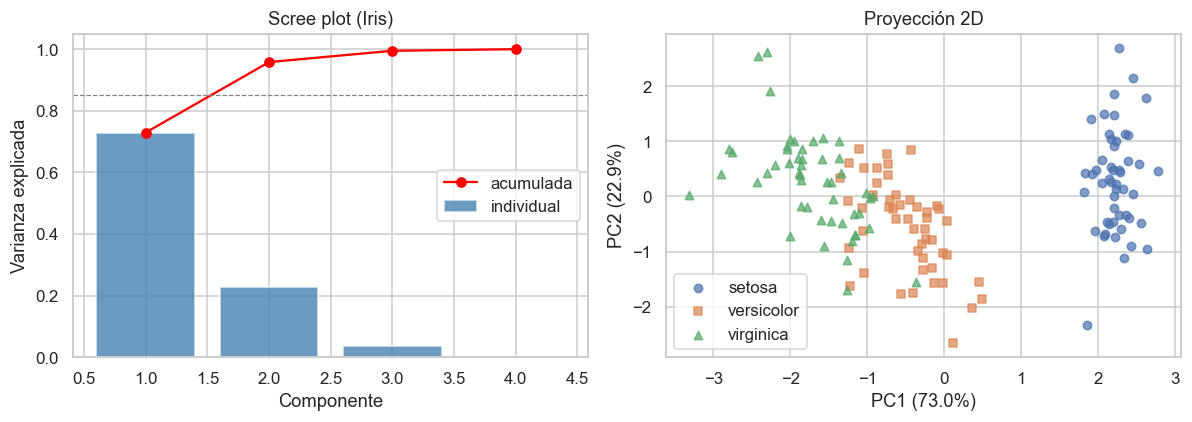

In [19]:
# Visualización: scree plot + proyección 2D
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(range(1, p+1), lam/lam.sum(), color='steelblue', alpha=0.8, label='individual')
ax[0].plot(range(1, p+1), np.cumsum(lam/lam.sum()), 'o-', color='red', label='acumulada')
ax[0].axhline(0.85, color='gray', ls='--', lw=0.8)
ax[0].set_xlabel('Componente'); ax[0].set_ylabel('Varianza explicada')
ax[0].set_title('Scree plot (Iris)'); ax[0].legend()

for c, marker, name in zip(range(3), ['o','s','^'], iris.target_names):
    ax[1].scatter(Z[yi==c, 0], Z[yi==c, 1], marker=marker, s=30, alpha=0.7, label=name)
ax[1].set_xlabel(f'PC1 ({lam[0]/lam.sum()*100:.1f}%)')
ax[1].set_ylabel(f'PC2 ({lam[1]/lam.sum()*100:.1f}%)')
ax[1].set_title('Proyección 2D'); ax[1].legend()
plt.tight_layout(); plt.show()

In [20]:
# Ejercicio 7.2 — ACP sobre Heart Failure: ¿cuántas componentes para 85%?
X_hf_std = StandardScaler().fit_transform(
    np.column_stack([
        df_hf['age'], df_hf['ejection_fraction'], df_hf['serum_creatinine'],
        df_hf['serum_sodium'], df_hf['time'],
        np.log1p(df_hf['creatinine_phosphokinase']),
        np.log1p(df_hf['platelets']),
    ])
)
pca_hf = PCA().fit(X_hf_std)
vr = pca_hf.explained_variance_ratio_
vc = np.cumsum(vr)
n_85 = np.searchsorted(vc, 0.85) + 1
print(f'Varianza explicada por componente: {vr.round(3)}')
print(f'Acumulada: {vc.round(3)}')
print(f'Componentes necesarias para ≥ 85%: n = {n_85}')

# Loadings — qué variables aportan a PC1 y PC2
var_names = ['age','EF','sCr','sNa','time','log_CPK','log_plat']
loadings = pd.DataFrame(pca_hf.components_[:3].T,
                        index=var_names, columns=['PC1','PC2','PC3']).round(3)
print()
print('Loadings (primeras 3 CPs):')
print(loadings)

Varianza explicada por componente: [0.213 0.174 0.142 0.132 0.128 0.107 0.103]
Acumulada: [0.213 0.386 0.528 0.661 0.789 0.897 1.   ]
Componentes necesarias para ≥ 85%: n = 6

Loadings (primeras 3 CPs):
            PC1    PC2    PC3
age       0.483  0.321 -0.201
EF       -0.122  0.648 -0.204
sCr       0.509 -0.066 -0.036
sNa      -0.400  0.473 -0.205
time     -0.503 -0.175 -0.248
log_CPK  -0.246 -0.386 -0.029
log_plat -0.137  0.263  0.901


## 8. Descomposición en Valores Singulares (SVD)

### 8.1 Teorema fundamental

Toda matriz $\mathbf{A}\in\mathbb{R}^{n\times m}$ admite la factorización

$$
\mathbf{A} \;=\; \mathbf{U}\,\mathbf{S}\,\mathbf{V}^{\top},
$$

con $\mathbf{U}\in\mathbb{R}^{n\times n}$ y $\mathbf{V}\in\mathbb{R}^{m\times m}$ ortogonales, y $\mathbf{S}\in\mathbb{R}^{n\times m}$ diagonal con valores singulares $s_1\geq s_2\geq\dots\geq s_r\geq 0$, $r=\min(n,m)$.

### 8.2 Relación con ACP

Si $\mathbf{X}\in\mathbb{R}^{N\times p}$ está centrada y escribimos $\mathbf{X}=\mathbf{U}\mathbf{S}\mathbf{V}^{\top}$:

$$
\mathbf{X}^{\top}\mathbf{X} = \mathbf{V}\mathbf{S}^{\top}\mathbf{U}^{\top}\mathbf{U}\mathbf{S}\mathbf{V}^{\top} = \mathbf{V}\,\mathbf{S}^2\,\mathbf{V}^{\top}.
$$

Comparando con $(N-1)\hat{\boldsymbol{\Sigma}} = \mathbf{P}\,\bigl((N-1)\boldsymbol{\Lambda}\bigr)\,\mathbf{P}^{\top}$:

$$
\boxed{\;\mathbf{V} = \mathbf{P},\qquad s_i = \sqrt{(N-1)\,\lambda_i}\;}
$$

**Ventaja**: SVD evita formar explícitamente $\mathbf{X}^{\top}\mathbf{X}$ — más estable numéricamente, especialmente con $\kappa(\mathbf{X})$ grande.

### 8.3 Aplicaciones propias de SVD

- **Latent Semantic Indexing (LSI)**: descomposición de matrices término-documento.
- **Compresión / aproximación de rango bajo** (Eckart–Young): la mejor aproximación $\mathbf{A}_k$ de rango $k$ en norma de Frobenius es $\mathbf{U}_k\mathbf{S}_k\mathbf{V}_k^{\top}$.
- **Pseudoinversa de Moore–Penrose**: $\mathbf{A}^{+} = \mathbf{V}\mathbf{S}^{+}\mathbf{U}^{\top}$.

In [21]:
# Ejercicio 8.1 — Verificar V = P y s_i = sqrt((N-1)*lambda_i)
Xc = Xi - Xi.mean(axis=0)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)

print('Valores singulares:        ', s.round(4))
print('sqrt((N-1)*lambda_i):      ', np.sqrt((Xc.shape[0]-1)*lam).round(4))
print('Coinciden ✓')
print()
print('V (primera fila):', Vt[0].round(4))
print('P (primera col): ', P[:,0].round(4))
print('Iguales hasta signo (autovectores únicos hasta ±).')

Valores singulares:         [20.9231 11.7092  4.6919  1.7627]
sqrt((N-1)*lambda_i):       [20.9231 11.7092  4.6919  1.7627]
Coinciden ✓

V (primera fila): [ 0.5211 -0.2693  0.5804  0.5649]
P (primera col):  [-0.5211  0.2693 -0.5804 -0.5649]
Iguales hasta signo (autovectores únicos hasta ±).


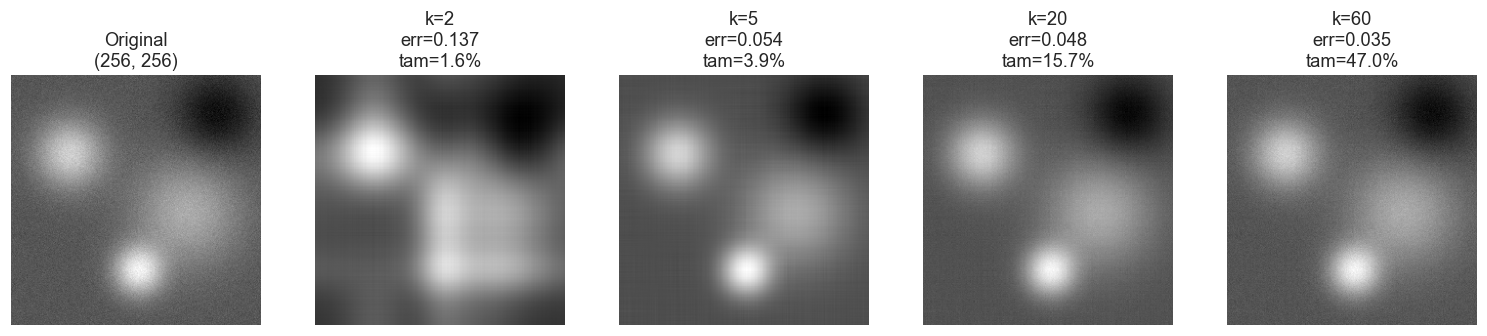

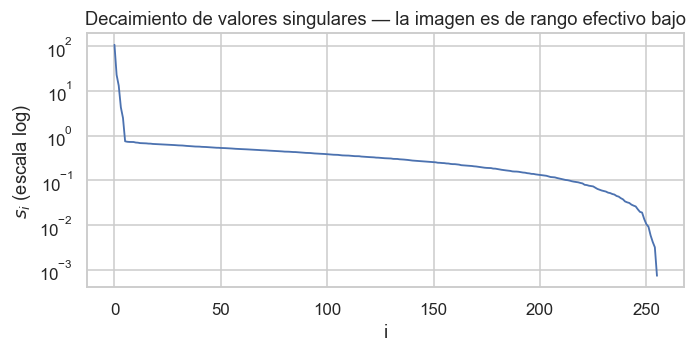

In [27]:
# Ejercicio 8.2 — Compresión por SVD truncada (Eckart–Young) sobre imagen sintética
# Construimos una "imagen" 256x256 con varias gaussianas + textura (rango efectivo ≈ 30)
H, W = 256, 256
yy, xx = np.mgrid[0:H, 0:W].astype(float)
img  = np.zeros((H, W))
for cx, cy, s, a in [(60,80,25,1.0), (180,140,40,0.7), (130,200,18,1.2), (210,40,30,-0.6)]:
    img += a * np.exp(-((xx-cx)**2 + (yy-cy)**2) / (2*s**2))
img += 0.05 * rng.normal(size=(H, W))   # textura/ruido
img = (img - img.min()) / (img.max() - img.min())

U, s, Vt = np.linalg.svd(img, full_matrices=False)

ks = [2, 5, 20, 60]
fig, ax = plt.subplots(1, len(ks)+1, figsize=(14, 3))
ax[0].imshow(img, cmap='gray'); ax[0].set_title(f'Original\n{img.shape}'); ax[0].axis('off')
for j, k in enumerate(ks, 1):
    img_k = U[:,:k] @ np.diag(s[:k]) @ Vt[:k,:]
    err   = np.linalg.norm(img - img_k)/np.linalg.norm(img)
    comp  = (H*k + k + k*W) / (H*W)
    ax[j].imshow(img_k, cmap='gray')
    ax[j].set_title(f'k={k}\nerr={err:.3f}\ntam={comp:.1%}'); ax[j].axis('off')
plt.tight_layout(); plt.show()

# Decaimiento de los valores singulares
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(s, lw=1.2)
ax.set_xlabel('i'); ax.set_ylabel('$s_i$ (escala log)')
ax.set_title('Decaimiento de valores singulares — la imagen es de rango efectivo bajo')
plt.show()

Con $k=50$ ya se obtiene una imagen perceptualmente similar usando ≈ 12% del tamaño original — la SVD captura la estructura redundante.

## 9. Análisis Discriminante Lineal (ADL / LDA)

### 9.1 Motivación

ACP ignora la variable de salida $\mathbf{y}$. Si las clases están separadas en una dirección de **baja** varianza, ACP la descartará.

### 9.2 Descomposición de la varianza (Fisher, 1936)

Para $m$ clases con $N_c$ observaciones y centroide $\bar{\mathbf{x}}_c$:

$$
\boldsymbol{\Sigma}_T \;=\; \underbrace{\sum_{c=1}^{m} N_c (\bar{\mathbf{x}}_c-\bar{\mathbf{x}})(\bar{\mathbf{x}}_c-\bar{\mathbf{x}})^{\top}}_{\boldsymbol{\Sigma}_B \text{ (between)}}
\;+\; \underbrace{\sum_{c=1}^{m}\sum_{t\in c} (\mathbf{x}(t)-\bar{\mathbf{x}}_c)(\mathbf{x}(t)-\bar{\mathbf{x}}_c)^{\top}}_{\boldsymbol{\Sigma}_W \text{ (within)}}.
$$

### 9.3 Problema de optimización

Buscar la dirección $\mathbf{v}$ que **maximiza la separación entre clases** y **minimiza la dispersión interna**:

$$
\mathbf{v}^{*} \;=\; \arg\max_{\mathbf{v}} \;
\frac{\mathbf{v}^{\top}\boldsymbol{\Sigma}_B \mathbf{v}}{\mathbf{v}^{\top}\boldsymbol{\Sigma}_W \mathbf{v}}.
$$

Solución: problema de **autovalores generalizado**

$$
\boldsymbol{\Sigma}_B\,\mathbf{V} \;=\; \boldsymbol{\Sigma}_W\,\mathbf{V}\,\boldsymbol{\Lambda}.
$$

El número máximo de direcciones discriminantes es $\min(p,m-1)$.

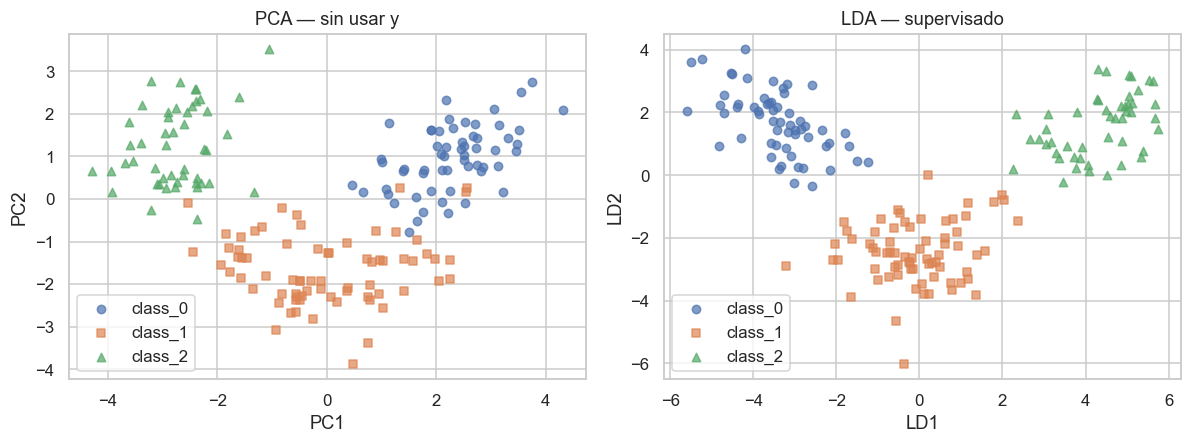

Fisher score PCA: 3.762
Fisher score LDA: 7.105  ← mejor por construcción


In [24]:
# Ejercicio 9.1 — Comparar PCA vs LDA sobre Wine (3 clases, 13 variables)
wine = load_wine()
Xw = StandardScaler().fit_transform(wine.data)
yw = wine.target

Z_pca = PCA(n_components=2).fit_transform(Xw)
Z_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(Xw, yw)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for c, marker in zip(range(3), ['o','s','^']):
    ax[0].scatter(Z_pca[yw==c,0], Z_pca[yw==c,1], marker=marker, s=30, alpha=0.7,
                  label=wine.target_names[c])
    ax[1].scatter(Z_lda[yw==c,0], Z_lda[yw==c,1], marker=marker, s=30, alpha=0.7,
                  label=wine.target_names[c])
ax[0].set_title('PCA — sin usar y'); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2'); ax[0].legend()
ax[1].set_title('LDA — supervisado');  ax[1].set_xlabel('LD1'); ax[1].set_ylabel('LD2'); ax[1].legend()
plt.tight_layout(); plt.show()

# Cuantificar separación: distancia entre centroides / dispersión interna
def fisher_score(Z, y):
    cents = np.array([Z[y==c].mean(axis=0) for c in np.unique(y)])
    SB = np.var(cents, axis=0).sum()
    SW = np.mean([np.var(Z[y==c], axis=0).sum() for c in np.unique(y)])
    return SB / SW

print(f'Fisher score PCA: {fisher_score(Z_pca, yw):.3f}')
print(f'Fisher score LDA: {fisher_score(Z_lda, yw):.3f}  ← mejor por construcción')

## 10. Análisis de Correlación Canónica (ACC / CCA)

Tenemos dos bloques de variables:
- $\mathbf{X}\in\mathbb{R}^{N\times p}$ (predictores)
- $\mathbf{Y}\in\mathbb{R}^{N\times q}$ (respuestas)

Buscamos pares de transformaciones lineales $\mathbf{u}_x\in\mathbb{R}^p$, $\mathbf{u}_y\in\mathbb{R}^q$ que maximicen la correlación entre las **variables canónicas**:

$$
\rho_1 \;=\; \max_{\mathbf{u}_x,\mathbf{u}_y}\;
\frac{\mathbf{u}_x^{\top}\hat{\boldsymbol{\Sigma}}_{XY}\mathbf{u}_y}
     {\sqrt{\mathbf{u}_x^{\top}\hat{\boldsymbol{\Sigma}}_{XX}\mathbf{u}_x}\,
      \sqrt{\mathbf{u}_y^{\top}\hat{\boldsymbol{\Sigma}}_{YY}\mathbf{u}_y}}.
$$

**Algoritmo** (estable):
1. Descomposición QR: $\mathbf{X}=\mathbf{Q}_x\mathbf{R}_x$, $\mathbf{Y}=\mathbf{Q}_y\mathbf{R}_y$.
2. SVD de $\mathbf{Q}_x^{\top}\mathbf{Q}_y = \tilde{\mathbf{U}}\,\boldsymbol{\rho}\,\tilde{\mathbf{V}}^{\top}$.
3. Las **correlaciones canónicas** son los valores singulares $\rho_1\geq\rho_2\geq\dots\geq 0$.
4. $\mathbf{U}_x = \mathbf{R}_x^{-1}\tilde{\mathbf{U}}$, $\mathbf{U}_y=\mathbf{R}_y^{-1}\tilde{\mathbf{V}}$.

Correlaciones canónicas: [0.9699 0.0378 0.0337]


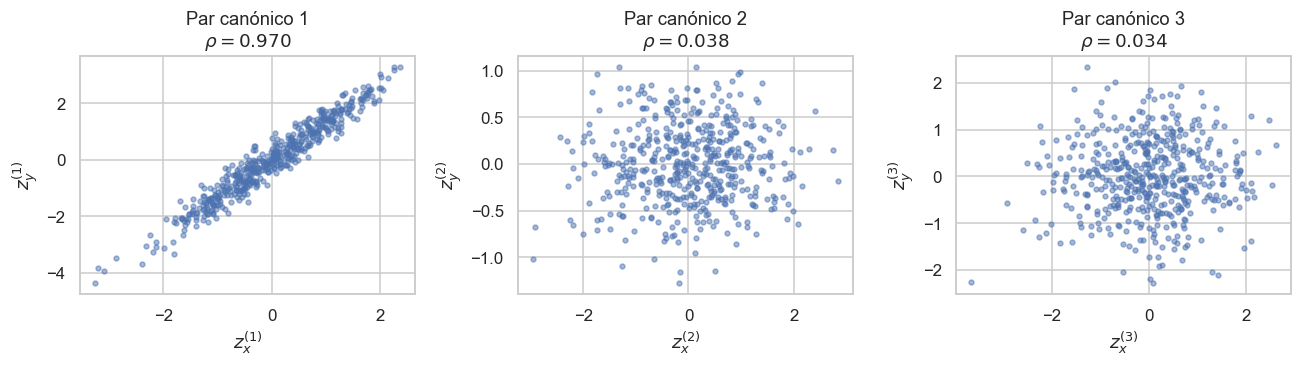

In [25]:
# Ejercicio 10.1 — CCA sobre datos sintéticos donde Y depende linealmente de X + ruido
n = 500
X = rng.normal(size=(n, 4))
# Construimos Y de manera que la combinación (1,1,0,0) en X se correlacione con (1,-1) en Y
Y = np.column_stack([
    1.0*X[:,0] + 1.0*X[:,1] + 0.5*rng.normal(size=n),
    -1.0*X[:,0] - 1.0*X[:,1] + 0.5*rng.normal(size=n),
    rng.normal(size=n)  # ruido puro
])

cca = CCA(n_components=3).fit(X, Y)
Zx, Zy = cca.transform(X, Y)
rhos = [stats.pearsonr(Zx[:,i], Zy[:,i])[0] for i in range(3)]
print('Correlaciones canónicas:', np.round(rhos, 4))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
for i in range(3):
    ax[i].scatter(Zx[:,i], Zy[:,i], s=10, alpha=0.5)
    ax[i].set_title(f'Par canónico {i+1}\n$\\rho={rhos[i]:.3f}$')
    ax[i].set_xlabel(f'$z_x^{{({i+1})}}$'); ax[i].set_ylabel(f'$z_y^{{({i+1})}}$')
plt.tight_layout(); plt.show()

Las dos primeras correlaciones canónicas son altas (corresponden a las direcciones que construimos); la tercera es despreciable (sólo ruido). CCA es la herramienta natural cuando **ambos** lados son vectoriales (e.g. comportamiento + neuro, expresión génica + fenotipo, audio + texto).

## 11. Aplicación: validación de sensores por ecuaciones de paridad

### 11.1 Planteamiento

Sistema lineal estático con $n$ estados verdaderos $\mathbf{s}\in\mathbb{R}^n$ medido por $p$ sensores ($p>n$):

$$
\mathbf{x}(t) \;=\; \mathbf{C}\,\mathbf{s}(t) \;+\; \boldsymbol{\varepsilon}(t),
\qquad \mathbf{C}\in\mathbb{R}^{p\times n}.
$$

El espacio de medidas válido es de dimensión $n$; existe un complemento ortogonal $\mathbf{W}\in\mathbb{R}^{p\times(p-n)}$ tal que $\mathbf{C}^{\top}\mathbf{W}=\mathbf{0}$.

### 11.2 Construcción vía PCA

Las primeras $n$ componentes principales de $\mathbf{X}$ generan $\mathbf{C}$; las últimas $p-n$ generan $\mathbf{W}$. El **vector de paridades** es

$$
\mathbf{u}(t) \;=\; \mathbf{x}(t)\,\mathbf{W} \;\in\;\mathbb{R}^{p-n}.
$$

Bajo operación normal, $\mathbf{u}(t)\approx\mathbf{0}$ (sólo ruido). Una falla en un sensor proyecta una señal **no nula** en una dirección típica del espacio de paridades.

### 11.3 Umbral de detección

$$
\xi \;=\; \sqrt{\sum_{i=n+1}^{p}\lambda_i}
$$

(la energía residual esperada por ruido). Se declara **alarma** si $\|\mathbf{u}(t)\| > \xi$.

Autovalores: [4.9289e+00 6.8200e-02 1.0300e-02 1.5000e-03 1.2000e-03]
Los primeros 2 autovalores acumulan 99.74% de la varianza
ξ = sqrt(Σ λ_3^5) = 0.1135
Umbral 3·ξ = 0.3405
Verificación C_hat^T W ≈ 0: max|.| = 1.64e-16


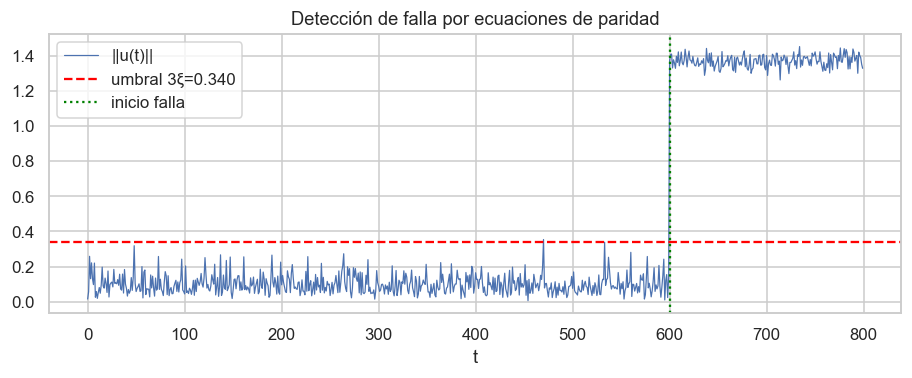

Alarmas antes de t=600: 0.2% (falsos positivos)
Alarmas después t=600: 100.0% (detección)


In [29]:
# Ejercicio 11.1 — Simular sistema con n=2 estados, p=5 sensores e inyectar falla
rng_loc = np.random.default_rng(7)
n_states, p_sensors, T = 2, 5, 800

# Estados verdaderos (solo 2 grados de libertad reales)
S = np.column_stack([np.sin(np.linspace(0, 12, T)),
                     np.cos(np.linspace(0, 9,  T))])
C_true = rng_loc.normal(size=(p_sensors, n_states))
noise  = 0.03 * rng_loc.normal(size=(T, p_sensors))
X_meas = S @ C_true.T + noise

# Calibración con datos NORMALES (primeras 500 muestras)
X_cal = X_meas[:500]
scaler = StandardScaler().fit(X_cal)
Xc = scaler.transform(X_cal)
Sigma = np.cov(Xc, rowvar=False)
lam, P = np.linalg.eigh(Sigma)
orden = np.argsort(lam)[::-1]
lam = lam[orden]; P = P[:, orden]

# Particionar P = [C | W]
C_hat = P[:, :n_states]
W     = P[:, n_states:]
xi_base = np.sqrt(lam[n_states:].sum())   # energía esperada del residual
umbral  = 3 * xi_base                     # regla 3σ
print(f'Autovalores: {lam.round(4)}')
print(f'Los primeros {n_states} autovalores acumulan {lam[:n_states].sum()/lam.sum()*100:.2f}% de la varianza')
print(f'ξ = sqrt(Σ λ_{n_states+1}^{p_sensors}) = {xi_base:.4f}')
print(f'Umbral 3·ξ = {umbral:.4f}')
print(f'Verificación C_hat^T W ≈ 0: max|.| = {np.abs(C_hat.T @ W).max():.2e}')

# Inyectar FALLA en sensor 2 desde t=600 (bias persistente grande respecto al ruido)
X_falla = X_meas.copy()
X_falla[600:, 2] += 1.5

# Calcular vector de paridades en TODO el periodo
Xn = scaler.transform(X_falla)
U_par = Xn @ W
norm_u = np.linalg.norm(U_par, axis=1)

fig, ax = plt.subplots(figsize=(10, 3.3))
ax.plot(norm_u, lw=0.8, label='||u(t)||')
ax.axhline(umbral, color='red', ls='--', label=f'umbral 3ξ={umbral:.3f}')
ax.axvline(600, color='green', ls=':', label='inicio falla')
ax.set_title('Detección de falla por ecuaciones de paridad')
ax.set_xlabel('t'); ax.legend(); plt.show()

print(f'Alarmas antes de t=600: {(norm_u[:600] > umbral).mean()*100:.1f}% (falsos positivos)')
print(f'Alarmas después t=600: {(norm_u[600:] > umbral).mean()*100:.1f}% (detección)')

El residual $\|\mathbf{u}(t)\|$ permanece bajo el umbral mientras los sensores funcionan correctamente, y dispara alarma sostenida cuando aparece el bias en el sensor 2.

Este es el principio que se aplicó en la **hidroeléctrica de Funil** (Evsukoff, 2020) para validar extensómetros con tasa significativa de valores faltantes.

## 12. Conclusiones

| Etapa | Idea matemática central | Riesgo si se omite |
|---|---|---|
| Caracterización | media, varianza, $\hat{\mathbf{R}}$ | Modelar ruido o redundancia |
| Distancias | norma adecuada (Mahalanobis con $\hat{\boldsymbol{\Sigma}}^{-1}$) | Outliers invisibles |
| Estandarización | z-score, log + z-score | PCA dominado por la unidad de medida |
| Outliers | 3σ, IQR, Algoritmo 2.1 | Modelos sesgados / no robustos |
| Faltantes | kNN imputer (Algoritmo 2.2) | Pérdida o sesgo de datos |
| ACP | $\hat{\boldsymbol{\Sigma}}\mathbf{p}=\lambda\mathbf{p}$ | Maldición de la dimensión |
| SVD | $\mathbf{X}=\mathbf{U}\mathbf{S}\mathbf{V}^{\top}$ | Inestabilidad numérica al formar $\mathbf{X}^{\top}\mathbf{X}$ |
| LDA | $\boldsymbol{\Sigma}_B\mathbf{v}=\lambda\boldsymbol{\Sigma}_W\mathbf{v}$ | Proyectar perdiendo discriminación |
| CCA | SVD de $\mathbf{Q}_x^{\top}\mathbf{Q}_y$ | Ignorar acoplamiento entre bloques |

**Mensajes finales**:

1. **El 60–80% del esfuerzo** de un proyecto de minería de datos está aquí, no en el modelo. Hacer EDA cuidadoso paga.
2. Las técnicas lineales (ACP, SVD, LDA, CCA) **descansan sobre la matriz de covarianza** y, por tanto, sobre estandarización + tratamiento previo de outliers/faltantes. Un solo paso descuidado las contamina.
3. Existen extensiones no lineales (**ICA**, **LLE**, **kernel PCA**, **autoencoders**) que se cubren más adelante; pero el armazón conceptual es el mismo: encontrar una representación más informativa con menos coordenadas.

### Referencias

- **Evsukoff, A. (2020)**. *Inteligência Computacional: Fundamentos e Aplicações*, Cap. 2. E-papers.
- **Bishop, C. (2006)**. *Pattern Recognition and Machine Learning*, Cap. 12 (PCA, probabilistic PCA).
- **Hastie, T. et al. (2009)**. *The Elements of Statistical Learning*, §3.5 y §14.5.
- **Han, J. et al. (2011)**. *Data Mining: Concepts and Techniques*, Cap. 2 y 3 (data preprocessing).
- **Prof. Max Chacón (USACH)**. *Capítulo II — ACP*, material del curso.